Question 1: Customer Purchase Analysis

In [1]:
import pandas as pd

data = {
    'Customer_ID': [101, 102, 103, 101, 104, 102, 101, 105, 102, 103],
    'Purchase_Amount': [200, 150, 180, 220, 300, 200, 100, 400, 250, 300]
}

df = pd.DataFrame(data)

# Group by Customer_ID and sum purchases
total_purchases = df.groupby('Customer_ID')['Purchase_Amount'].sum().reset_index()

print("Total Purchases per Customer:")
print(total_purchases)

# Top 3 frequent customers
top3 = total_purchases.nlargest(3, 'Purchase_Amount').reset_index(drop=True)

print("\nTop 3 Frequent Customers:")
print(top3)

Total Purchases per Customer:
   Customer_ID  Purchase_Amount
0          101              520
1          102              600
2          103              480
3          104              300
4          105              400

Top 3 Frequent Customers:
   Customer_ID  Purchase_Amount
0          102              600
1          101              520
2          103              480


Question 2: Outlier Detection using IQR

In [5]:
import pandas as pd
import numpy as np

data = {
    'Day': range(1, 31),
    'Sales': [25, 30, 28, 45, 55, 60, 22, 80, 95, 120, 33, 29, 27, 35, 40, 
              50, 85, 110, 105, 92, 30, 34, 31, 33, 36, 42, 44, 48, 90, 200]
}

df = pd.DataFrame(data)

# Calculate Q1, Q3 and IQR
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")

# Detect outliers
outliers = df[(df['Sales'] < lower_bound) | (df['Sales'] > upper_bound)]
print("\nOutliers Detected:")
print(outliers)

# Replace outliers with median
median = df['Sales'].median()
df_clean = df.copy()
df_clean.loc[(df_clean['Sales'] < lower_bound) | (df_clean['Sales'] > upper_bound), 'Sales'] = median

print("\nData After Replacing Outliers with Median:")
print(df_clean)

Q1: 31.5, Q3: 83.75, IQR: 52.25
Lower Bound: -46.875, Upper Bound: 162.125

Outliers Detected:
    Day  Sales
29   30    200

Data After Replacing Outliers with Median:
    Day  Sales
0     1     25
1     2     30
2     3     28
3     4     45
4     5     55
5     6     60
6     7     22
7     8     80
8     9     95
9    10    120
10   11     33
11   12     29
12   13     27
13   14     35
14   15     40
15   16     50
16   17     85
17   18    110
18   19    105
19   20     92
20   21     30
21   22     34
22   23     31
23   24     33
24   25     36
25   26     42
26   27     44
27   28     48
28   29     90
29   30     43


Question 3: Independent T-Test for Drug Effectiveness

In [7]:
import pandas as pd
from scipy import stats

data = {
    'Group': ['Treatment']*10 + ['Control']*10,
    'Blood_Pressure': [120, 115, 118, 123, 122, 119, 124, 117, 116, 121,
                       130, 135, 140, 138, 142, 136, 139, 134, 137, 141]
}

df = pd.DataFrame(data)

treatment = df[df['Group'] == 'Treatment']['Blood_Pressure']
control = df[df['Group'] == 'Control']['Blood_Pressure']

# Perform Independent T-Test
t_stat, p_value = stats.ttest_ind(treatment, control)

print(f"T-Statistic: {t_stat}")
print(f"P-Value: {p_value}")

# Conclusion
if p_value < 0.05:
    print("Reject the Null Hypothesis: The drug has a significant effect.")
else:
    print("Fail to Reject the Null Hypothesis: No significant effect.")

T-Statistic: -11.870553692962726
P-Value: 6.008066605173374e-10
Reject the Null Hypothesis: The drug has a significant effect.


Null Hypothesis (H₀): There is no significant difference in blood pressure between Treatment and Control groups.
Alternative Hypothesis (H₁): There is a significant difference.

Question 4: Covariance & Correlation Analysis

In [9]:
import pandas as pd
import numpy as np

# Assuming the dataset (you can replace with actual data)
data = {
    'TV_Ads': [100, 150, 200, 250, 300, 350, 400, 450, 500, 550],
    'Social_Media_Ads': [80, 120, 160, 200, 240, 280, 320, 360, 400, 440],
    'Sales': [5000, 6200, 7500, 8900, 10200, 11500, 12800, 14000, 15300, 16500]
}

df = pd.DataFrame(data)

# Covariance
cov_tv = df['TV_Ads'].cov(df['Sales'])
cov_social = df['Social_Media_Ads'].cov(df['Sales'])

# Correlation
corr_tv = df['TV_Ads'].corr(df['Sales'])
corr_social = df['Social_Media_Ads'].corr(df['Sales'])

print(f"Covariance (TV vs Sales): {cov_tv}")
print(f"Covariance (Social Media vs Sales): {cov_social}")
print(f"Correlation (TV vs Sales): {corr_tv}")
print(f"Correlation (Social Media vs Sales): {corr_social}")

if corr_tv > corr_social:
    print("TV Ads have a stronger impact on Sales.")
else:
    print("Social Media Ads have a stronger impact on Sales.")

Covariance (TV vs Sales): 590833.3333333333
Covariance (Social Media vs Sales): 472666.6666666666
Correlation (TV vs Sales): 0.9998753584269104
Correlation (Social Media vs Sales): 0.9998753584269104
Social Media Ads have a stronger impact on Sales.


Question 5: Delivery Time Analysis + PDF Plot

Mean Delivery Time: 65.0625
Standard Deviation of Delivery Time: 41.718504212759115


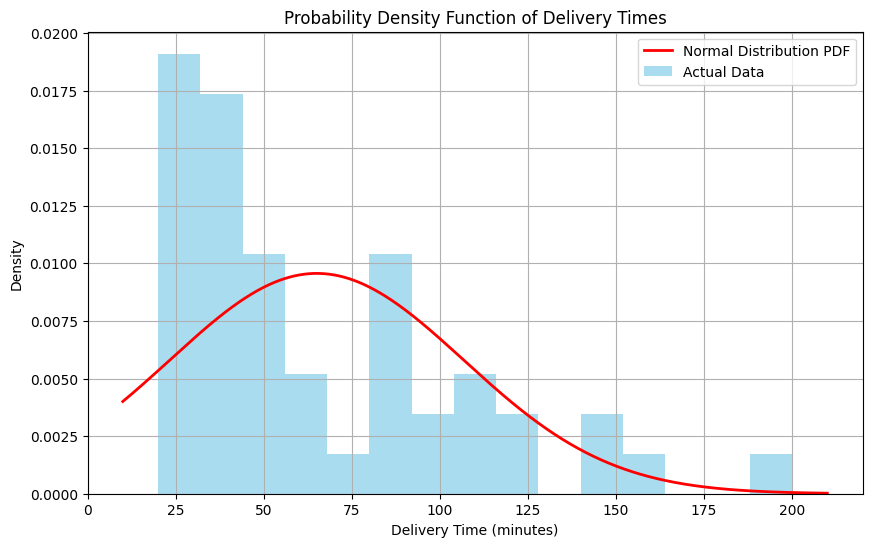

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

delivery_times = [25, 30, 28, 45, 55, 60, 22, 80, 95, 120, 33, 29, 27, 35, 40, 
                  50, 85, 110, 105, 92, 30, 34, 31, 33, 36, 42, 44, 48, 90, 200,
                  20, 25, 27, 32, 38, 41, 47, 58, 62, 77, 80, 84, 90, 110, 123, 
                  145, 150, 160]

mean = np.mean(delivery_times)
std = np.std(delivery_times)

print(f"Mean Delivery Time: {mean}")
print(f"Standard Deviation of Delivery Time: {std}")

# Plot Probability Density Function (PDF)
plt.figure(figsize=(10, 6))
x = np.linspace(min(delivery_times)-10, max(delivery_times)+10, 1000)
pdf = norm.pdf(x, mean, std)

plt.plot(x, pdf, 'r-', linewidth=2, label='Normal Distribution PDF')
plt.hist(delivery_times, bins=15, density=True, alpha=0.7, color='skyblue', label='Actual Data')
plt.title('Probability Density Function of Delivery Times')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()